In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from rich import print

In [ ]:
df = pd.read_parquet('CustomerData.parquet')

In [ ]:
df.head()

,Customer ID,Dollars Spent 2021,Dollars Spent 2022
0,9c7cdc4c-18fd-47ba-a304-a69fd69e4326,45.636204,69.364189
1,9e30f633-4dc3-4200-831c-a5dacc53ed13,40.311935,65.053696
2,342178ad-b68d-410d-a840-2d73624f9ba2,29.037670,61.948933
3,8f4657d9-a63a-4dfa-b429-d31cb3633d79,97.266983,112.984993
4,c18da3ee-7005-49da-abf0-8070170f3dc8,44.905178,51.551075


In [ ]:
X = df['Dollars Spent 2021']
y= df['Dollars Spent 2022']

In [ ]:
df['treatment'] = (df['Dollars Spent 2021'] > 80).astype(int)

In [ ]:
df['interaction'] = df['Dollars Spent 2021'] * df['treatment']

In [ ]:
model = smf.ols('y ~ X + treatment + interaction', data=df).fit()
print(model.summary())

OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                 7.054e+04
Date:                Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                        19:49:40   Log-Likelihood:                -74425.
No. Observations:               20000   AIC:                         1.489e+05
Df Residuals:                   19996   BIC:                         1.489e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       9.8443      0.210     46.930      0.000       9.433      10.255
X               1.1017      0.005    228.767      0.000       1.092       1.111
treatment      12.4675      0.749     16.635      0.000      10.998      13.937
interaction    -0.1190      0.008    -15.021      0.000      -0.135      -0.104
==============================================================================
Omnibus:                        2.531   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.282   Jarque-Bera (JB):                2.506
Skew:                           0.013   Prob(JB):                        0.286
Kurtosis:                       2.952   Cond. No.                         716.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

Testing different bandwidths

In [ ]:
def filter_data_by_bandwidth(df, threshold, bandwidth):
    lower_bound = threshold - bandwidth
    upper_bound = threshold + bandwidth

    filtered_df = df[(X >= lower_bound) &
                     (X <= upper_bound)]

    return filtered_df

In [ ]:
for bandwidth in [5, 10, 15, 20, 25]:
    # Create a subset of your data with the chosen bandwidth
    df_subset = filter_data_by_bandwidth(df, threshold=80, bandwidth=bandwidth)

    # Fit the model
    model = smf.ols('Q("Dollars Spent 2022") ~ Q("Dollars Spent 2021") + treatment + interaction', data=df_subset).fit()
    # Print the summary to compare the results
    print(f"Bandwidth: {bandwidth}")
    print(model.summary())

Bandwidth: 5

OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("Dollars Spent 2022")   R-squared:                       0.232
Model:                                 OLS   Adj. R-squared:                  0.230
Method:                      Least Squares   F-statistic:                     90.12
Date:                     Thu, 05 Dec 2024   Prob (F-statistic):           5.89e-51
Time:                             19:49:41   Log-Likelihood:                -3330.3
No. Observations:                      898   AIC:                             6669.
Df Residuals:                          894   BIC:                             6688.
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  11.1637     23.366      0.478      0.633     -34.695      57.022
Q("Dollars Spent 2021")     1.0777      0.301      3.575      0.000       0.486       1.669
treatment                  10.4790     36.389      0.288      0.773     -60.939      81.897
interaction                -0.0642      0.453     -0.142      0.887      -0.954       0.825
==============================================================================
Omnibus:                        0.884   Durbin-Watson:                   1.928
Prob(Omnibus):                  0.643   Jarque-Bera (JB):                0.965
Skew:                          -0.066   Prob(JB):                        0.617
Kurtosis:                       2.909   Cond. No.                     1.09e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+04. This might indicate that there are
strong multicollinearity or other numerical problems.

Bandwidth: 10

OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("Dollars Spent 2022")   R-squared:                       0.416
Model:                                 OLS   Adj. R-squared:                  0.415
Method:                      Least Squares   F-statistic:                     434.1
Date:                     Thu, 05 Dec 2024   Prob (F-statistic):          5.74e-213
Time:                             19:49:41   Log-Likelihood:                -6793.7
No. Observations:                     1834   AIC:                         1.360e+04
Df Residuals:                         1830   BIC:                         1.362e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   9.5301      7.707      1.237      0.216      -5.585      24.645
Q("Dollars Spent 2021")     1.1001      0.103     10.686      0.000       0.898       1.302
treatment                  15.3643     13.011      1.181      0.238     -10.153      40.882
interaction                -0.1263      0.161     -0.786      0.432      -0.442       0.189
==============================================================================
Omnibus:                        1.334   Durbin-Watson:                   1.971
Prob(Omnibus):                  0.513   Jarque-Bera (JB):                1.382
Skew:                          -0.063   Prob(JB):                        0.501
Kurtosis:                       2.952   Cond. No.                     5.45e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.45e+03. This might indicate that there are
strong multicollinearity or other numerical problems.

Bandwidth: 15

OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("Dollars Spent 2022")   R-squared:                       0.550
Model:                                 OLS   Adj. R-squared:                  0.549
Method:                      Least Squares   F-statistic:                     1143.
Date:                     Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                             19:49:41   Log-Likelihood:                -10411.
No. Observations:                     2813   AIC:                         2.083e+04
Df Residuals:                         2809   BIC:                         2.085e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   8.2728      3.861      2.142      0.032       0.701      15.844
Q("Dollars Spent 2021")     1.1170      0.054     20.846      0.000       1.012       1.222
treatment                  30.0459      7.232      4.155      0.000      15.865      44.227
interaction                -0.3037      0.088     -3.438      0.001      -0.477      -0.131
==============================================================================
Omnibus:                        2.768   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.251   Jarque-Bera (JB):                2.727
Skew:                          -0.076   Prob(JB):                        0.256
Kurtosis:                       3.021   Cond. No.                     3.61e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.61e+03. This might indicate that there are
strong multicollinearity or other numerical problems.

Bandwidth: 20

OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("Dollars Spent 2022")   R-squared:                       0.645
Model:                                 OLS   Adj. R-squared:                  0.644
Method:                      Least Squares   F-statistic:                     2365.
Date:                     Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                             19:49:41   Log-Likelihood:                -14557.
No. Observations:                     3918   AIC:                         2.912e+04
Df Residuals:                         3914   BIC:                         2.915e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  13.0049      2.342      5.553      0.000       8.414      17.596
Q("Dollars Spent 2021")     1.0532      0.034     31.092      0.000       0.987       1.120
treatment                  20.3405      4.838      4.204      0.000      10.855      29.826
interaction                -0.1812      0.058     -3.111      0.002      -0.295      -0.067
==============================================================================
Omnibus:                        0.511   Durbin-Watson:                   2.028
Prob(Omnibus):                  0.775   Jarque-Bera (JB):                0.466
Skew:                          -0.022   Prob(JB):                        0.792
Kurtosis:                       3.030   Cond. No.                     2.71e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.71e+03. This might indicate that there are
strong multicollinearity or other numerical problems.

Bandwidth: 25

OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("Dollars Spent 2022")   R-squared:                       0.712
Model:                                 OLS   Adj. R-squared:                  0.711
Method:                      Least Squares   F-statistic:                     4156.
Date:                     Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                             19:49:41   Log-Likelihood:                -18800.
No. Observations:                     5056   AIC:                         3.761e+04
Df Residuals:                         5052   BIC:                         3.763e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  11.9141      1.574      7.568      0.000       8.828      15.000
Q("Dollars Spent 2021")     1.0683      0.024     44.976      0.000       1.022       1.115
treatment                  23.0084      3.648      6.308      0.000      15.858      30.159
interaction                -0.2144      0.043     -4.965      0.000      -0.299      -0.130
==============================================================================
Omnibus:                        1.110   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.574   Jarque-Bera (JB):                1.067
Skew:                          -0.011   Prob(JB):                        0.587
Kurtosis:                       3.068   Cond. No.                     2.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.

In [ ]:
def filter_data_by_bandwidth(df, threshold, bandwidth):
    lower_bound = threshold - bandwidth
    upper_bound = threshold + bandwidth

    filtered_df = df[(df['Dollars Spent 2021'] >= lower_bound) &
                     (df['Dollars Spent 2021'] <= upper_bound)]

    return filtered_df

In [ ]:
print("Column names before renaming:", df.columns)

Column names before renaming: Index(['Customer ID', 'Dollars Spent 2021', 'Dollars Spent 2022', 'treatment',
       'interaction'],
      dtype='object')

In [ ]:
threshold = 80
bandwidth = 25

df_filtered = filter_data_by_bandwidth(df, threshold, bandwidth).copy()

df_filtered['treatment'] = (df_filtered['Dollars Spent 2021'] > threshold).astype(int)
df_filtered['interaction'] = df_filtered['Dollars Spent 2021'] * df_filtered['treatment']


OLS Regression Results                              
===================================================================================
Dep. Variable:     Q('Dollars Spent 2022')   R-squared:                       0.712
Model:                                 OLS   Adj. R-squared:                  0.711
Method:                      Least Squares   F-statistic:                     4156.
Date:                     Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                             19:49:41   Log-Likelihood:                -18800.
No. Observations:                     5056   AIC:                         3.761e+04
Df Residuals:                         5052   BIC:                         3.763e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            11.9141      1.574      7.568      0.000       8.828      15.000
Q('Dollars Spent 2021')               1.0683      0.024     44.976      0.000       1.022       1.115
threshold                            23.0084      3.648      6.308      0.000      15.858      30.159
Q('Dollars Spent 2021'):threshold    -0.2144      0.043     -4.965      0.000      -0.299      -0.130
==============================================================================
Omnibus:                        1.110   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.574   Jarque-Bera (JB):                1.067
Skew:                          -0.011   Prob(JB):                        0.587
Kurtosis:                       3.068   Cond. No.                     2.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.

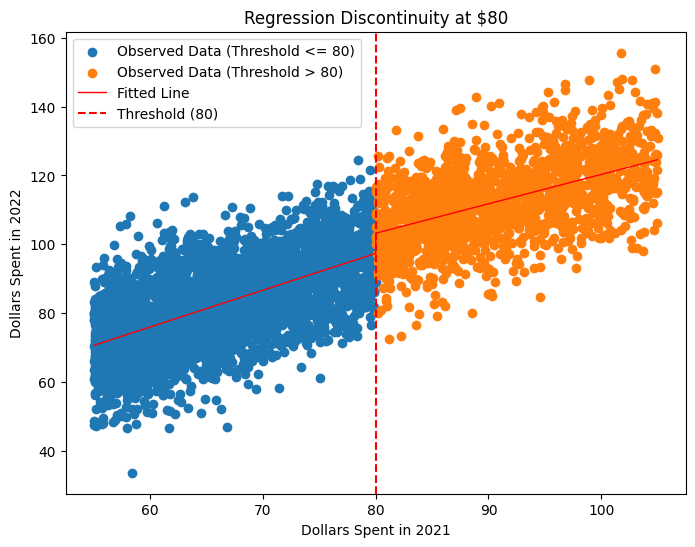

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df_filtered = df_filtered.assign(threshold=(df_filtered["Dollars Spent 2021"] > 80).astype(int))

model = smf.ols("Q('Dollars Spent 2022') ~ Q('Dollars Spent 2021') * threshold", data=df_filtered).fit()

print(model.summary())

df_filtered_sorted = df_filtered.sort_values(by="Dollars Spent 2021")

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df_filtered[df_filtered["threshold"] == 0]["Dollars Spent 2021"],
           df_filtered[df_filtered["threshold"] == 0]["Dollars Spent 2022"],
           color="C0", label="Observed Data (Threshold <= 80)")

ax.scatter(df_filtered[df_filtered["threshold"] == 1]["Dollars Spent 2021"],
           df_filtered[df_filtered["threshold"] == 1]["Dollars Spent 2022"],
           color="C1", label="Observed Data (Threshold > 80)")

df_filtered_sorted.assign(predictions=model.fittedvalues).plot(x="Dollars Spent 2021", y="predictions",
                                                               ax=ax, color="red", label="Fitted Line", linewidth=1)

plt.axvline(x=80, color="red", linestyle="--", label="Threshold (80)")

plt.title("Regression Discontinuity at $80")
plt.xlabel("Dollars Spent in 2021")
plt.ylabel("Dollars Spent in 2022")
plt.legend()
plt.show()

OLS Regression Results                              
===================================================================================
Dep. Variable:     Q('Dollars Spent 2022')   R-squared:                       0.712
Model:                                 OLS   Adj. R-squared:                  0.711
Method:                      Least Squares   F-statistic:                     4156.
Date:                     Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                             19:49:42   Log-Likelihood:                -18800.
No. Observations:                     5056   AIC:                         3.761e+04
Df Residuals:                         5052   BIC:                         3.763e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            11.9141      1.574      7.568      0.000       8.828      15.000
Q('Dollars Spent 2021')               1.0683      0.024     44.976      0.000       1.022       1.115
threshold                            23.0084      3.648      6.308      0.000      15.858      30.159
Q('Dollars Spent 2021'):threshold    -0.2144      0.043     -4.965      0.000      -0.299      -0.130
==============================================================================
Omnibus:                        1.110   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.574   Jarque-Bera (JB):                1.067
Skew:                          -0.011   Prob(JB):                        0.587
Kurtosis:                       3.068   Cond. No.                     2.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.

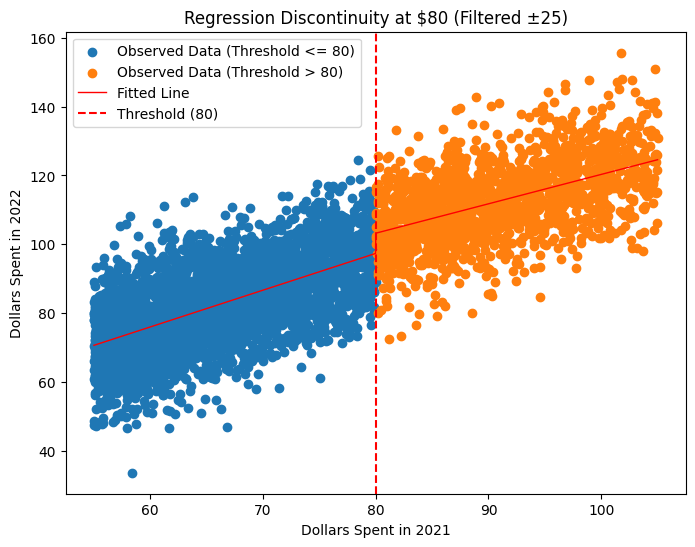

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df_filtered = df_filtered[
    (df_filtered["Dollars Spent 2021"].between(55, 105))
]

df_filtered = df_filtered.assign(threshold=(df_filtered["Dollars Spent 2021"] > 80).astype(int))

model = smf.ols("Q('Dollars Spent 2022') ~ Q('Dollars Spent 2021') * threshold", data=df_filtered).fit()

print(model.summary())

df_filtered_sorted = df_filtered.sort_values(by="Dollars Spent 2021")

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df_filtered[df_filtered["threshold"] == 0]["Dollars Spent 2021"],
           df_filtered[df_filtered["threshold"] == 0]["Dollars Spent 2022"],
           color="C0", label="Observed Data (Threshold <= 80)")

ax.scatter(df_filtered[df_filtered["threshold"] == 1]["Dollars Spent 2021"],
           df_filtered[df_filtered["threshold"] == 1]["Dollars Spent 2022"],
           color="C1", label="Observed Data (Threshold > 80)")

df_filtered_sorted.assign(predictions=model.fittedvalues).plot(x="Dollars Spent 2021", y="predictions",
                                                               ax=ax, color="red", label="Fitted Line", linewidth=1)

plt.axvline(x=80, color="red", linestyle="--", label="Threshold (80)")

plt.title("Regression Discontinuity at $80 (Filtered ±25)")
plt.xlabel("Dollars Spent in 2021")
plt.ylabel("Dollars Spent in 2022")
plt.legend()
plt.show()
